### DIFFUSION PROCESS
Here are reported some diffusion processes and their numerical siimulations 

In [2]:
import numpy as np
import matplotlib.pyplot as plt

#### 1. BLACK-SCHOLES-MERTON
The process follows the Geometric Brownian motion
$$
\begin{align}

dS_t &= r S_t dt + \sigma S_t dZ_t \\
S_T &= S_0 e^{(r - \frac{1}{2}\sigma^2)T + \sigma \sqrt{T}z}

\end{align}
$$

- $r$ is the constant percentage drift 
- $\sigma$ is the constant percentage volatility
- $Z_t$ is the standard Brownian motion

Using a discretization method we have:
$$
S_{t} = S

$$

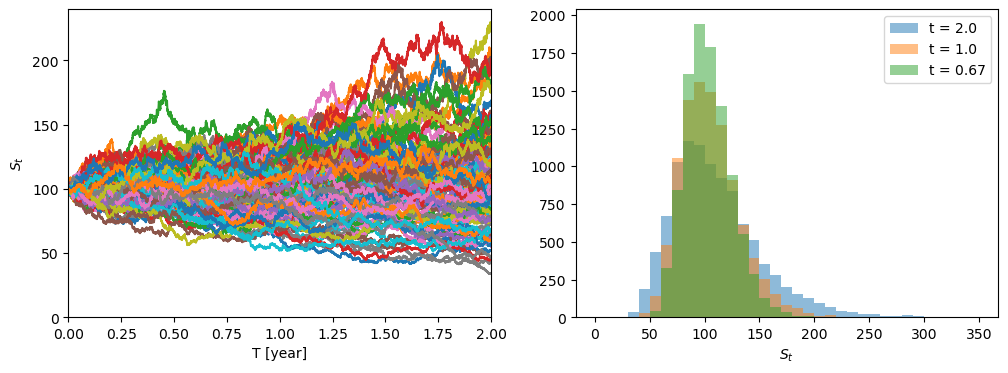

In [74]:
S0 = 100
r = 0.05
sigma = 0.25
T = 2
nProcesses = 10_000
nSteps = 10_000
dt = T / nSteps 

times = np.linspace(0, T, nSteps + 1)

# Independent standard normal increments
Z = np.random.normal(loc=0, scale=1, size=(nProcesses, nSteps))

St = np.empty((nProcesses, nSteps + 1))
St[:, 0] = S0
log_return_increments = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
St[:, 1:] = S0 * np.exp(np.cumsum(log_return_increments, axis=1))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for i in range(Z.shape[0]):
    ax[0].plot(times, St[i, :])
    if i > 100: break

ax[0].set_xlim(0, T)
ax[0].set_ylim(0, )
ax[0].set_xlabel('T [year]')
ax[0].set_ylabel(r'$S_t$')


for i in [1, 2, 3]:
    ax[1].hist(St[:, nSteps // i], bins=35, range=(0, 350), alpha=0.5, label=f't = {round(times[nSteps // i], 2)}')
ax[1].set_xlabel(r'$S_t$')
ax[1].legend()
plt.show()

#### 2. SQUARE-ROOT DIFFUSION

$$
dX_t = \kappa (\theta - X_t)dt + \sigma \sqrt{X_t} dZ_t
$$

- $\kappa$ is the constant mean-reversion factor
- $\theta$ is the long-run mean of the process
- $\sigma$ is the constant volatility
- $Z_t$ is the standard Brownian motion

Using Euler discretization scheme we can define $s = t - \Delta_t$ and $X^+ = max(X, 0)$ such that
$$
\begin{align}
\tilde{X_t} &= \tilde{X_s} + \kappa(\theta - \tilde{X_s}^+) \Delta_t + \sigma \sqrt{\tilde{X_s}^+} \sqrt{\Delta_t} z \\ 
X_t &= \tilde{X_t}^+
\end{align}
$$

The square-root diffusion has the convenient and realistic characteristic that the values of $X_t$ remain strictly positive

In [75]:
x0 = 0.05
kappa = 3.0
theta = 0.02
sigma = 0.1
nProcesses = 10_000
nSteps = 100
T = 4
dt = T / nSteps

times = np.linspace(0, T, nSteps + 1)

Z = np.random.normal(loc=0, scale=1, size=(nProcesses, nSteps))

Xt = np.empty((nProcesses, nSteps + 1), dtype=float)
Xt[:, 0] = x0

for t in range(nSteps):
    # Full truncation prevents square roots of negative values
    X_positive = np.maximum(Xt[:, t], 0.0)

    drift = kappa * (theta - X_positive) * dt
    diffusion = sigma * np.sqrt(X_positive) * np.sqrt(dt) * Z[:, t]

    Xt[:, t + 1] = np.maximum(Xt[:, t] + drift + diffusion, 0.0)

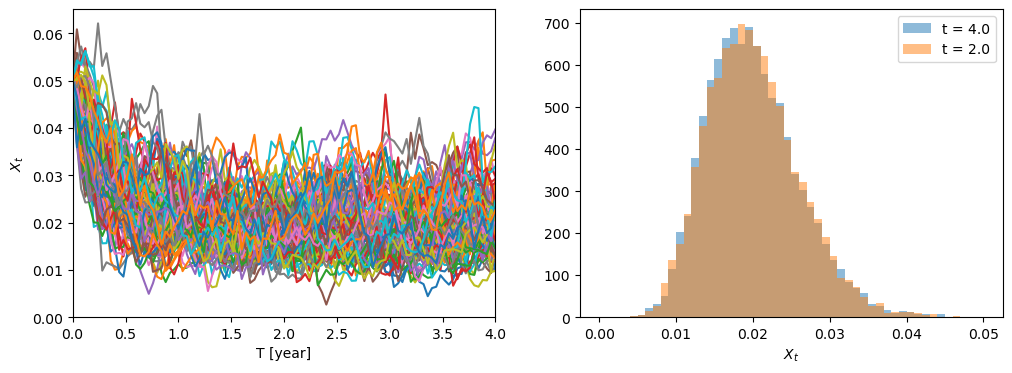

In [77]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for i in range(Xt.shape[0]):
    ax[0].plot(times, Xt[i])
    if i > 100: break

ax[0].set_xlim(0, T)
ax[0].set_ylim(0, )
ax[0].set_xlabel('T [year]')
ax[0].set_ylabel(r'$X_t$')

for i in [1, 2]:
    ax[1].hist(Xt[:, nSteps // i], bins=50, range=(0, 0.05), alpha=0.5, label=f't = {round(times[nSteps // i], 2)}')
ax[1].set_xlabel(r'$X_t$')
ax[1].legend()
plt.show()

#### 3. STOCHASTIC VOLATILITY MODEL (HESTON)

Major limitation of Black-Scholes-Merton is given by constant volatility which is rather stochastic, we then expand the BS model to the following:
$$
\begin{align}
dS_t &= r S_t dt + \sqrt{\nu_t} S_t dZ_{1,t} \\
d\nu_t &= \kappa(\theta - \nu_t)dt + \sigma \sqrt{\nu_t} Z_{2,t} \\
Corr(Z_{1,t}, Z_{2,t}) &= \rho
\end{align}
$$

In [100]:
S0 = 100
r = 0.05

v0 = 0.1
kappa = 3.0
theta = 0.25
sigma = 0.1
rho = 0.6

T = 1.0
nProcesses = 10_000
nSteps = 100

dt = T / nSteps
times = np.linspace(0, T, nSteps + 1)

corr_matrix = np.array([
    [1.0, rho],
    [rho, 1.0],
])

cho_matrix = np.linalg.cholesky(corr_matrix) # Cholesky decomposition

St = np.empty((nProcesses, nSteps + 1))
St[:, 0] = S0

v_t = np.empty((nProcesses, nSteps + 1))
v_t[:, 0] = v0

# Independent standard normal shocks
Z = np.random.normal(loc=0, scale=1, size=(2, nProcesses, nSteps))

for t in range(nSteps):
    # Produce correlated shocks
    Z_rotated = cho_matrix @ Z[:, :, t]

    Z_stock = Z_rotated[0]
    Z_variance = Z_rotated[1]

    # Full-truncation treatment of variance
    v_positive = np.maximum(v_t[:, t], 0.0)

    # CIR variance process
    v_t[:, t + 1] = (
        v_t[:, t]
        + kappa * (theta - v_positive) * dt
        + sigma * np.sqrt(v_positive) * np.sqrt(dt) * Z_variance
    )

    # Keep stored variance nonnegative
    v_t[:, t + 1] = np.maximum(v_t[:, t + 1], 0.0)

    # Exact GBM-style update conditional on current variance
    St[:, t + 1] = St[:, t] * np.exp(
        (r - 0.5 * v_positive) * dt
        + np.sqrt(v_positive) * np.sqrt(dt) * Z_stock
    )

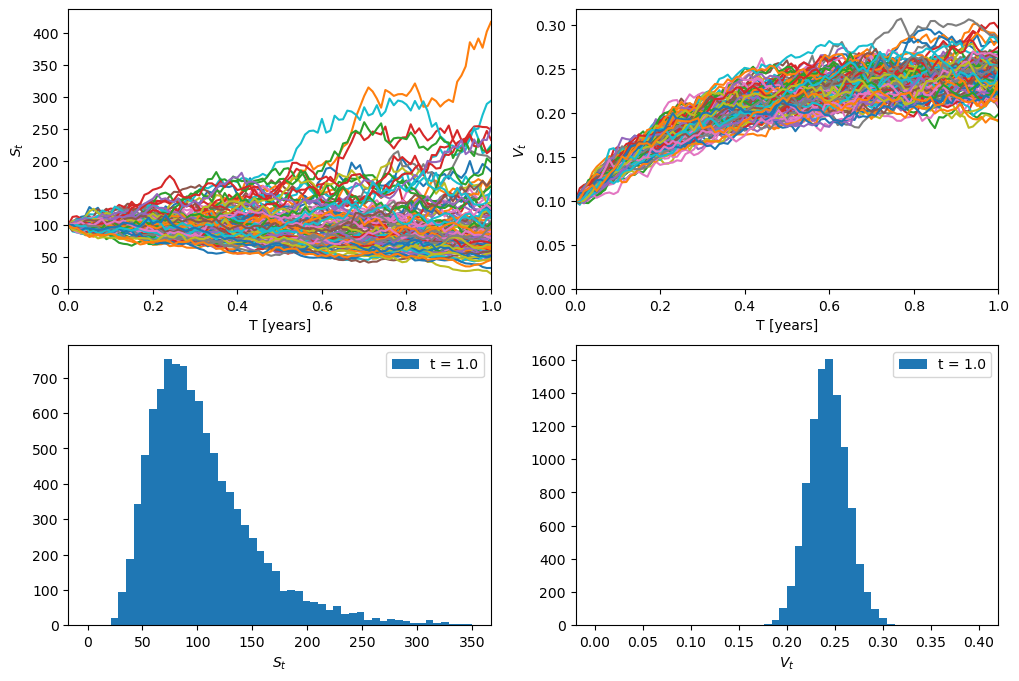

In [106]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.flatten()

for i in range(nProcesses):
    ax[0].plot(times, St[i, :])
    ax[1].plot(times, v_t[i, :])

    if i > 100: break

ax[0].set_xlim(0, T)
ax[0].set_ylim(0, )
ax[0].set_xlabel('T [years]')
ax[0].set_ylabel(r'$S_t$')

ax[1].set_xlim(0, T)
ax[1].set_ylim(0, )
ax[1].set_xlabel('T [years]')
ax[1].set_ylabel(r'$V_t$')

ax[2].hist(St[:, -1], bins=50, range=(0, 350), label=f't = {round(times[-1], 2)}')
ax[2].set_xlabel(r'$S_t$')
ax[2].legend()


ax[3].hist(v_t[:, -1], bins=50, range=(0, 0.4), label=f't = {round(times[-1], 2)}')
ax[3].set_xlabel(r'$V_t$')
ax[3].legend()

plt.show()